In [1]:
#ETAPE 5 - Préparation ----------------------------------------------------------------------------
import pandas as pd
import warnings
warnings.filterwarnings('ignore')




df = pd.read_csv("anssi_cve_consolidated.csv", sep=";")
print(f"Forme du DataFrame: {df.shape}")
print(f"{df.columns.tolist()}")

print(df.dtypes)
print(df.head())



Forme du DataFrame: (1282, 10)
['ID ANSSI', 'Titre', 'Type', 'Date', 'CVE', 'CVSS Score', 'CWE', 'EPSS Score', 'Description', 'Lien']
ID ANSSI        object
Titre           object
Type            object
Date            object
CVE             object
CVSS Score     float64
CWE             object
EPSS Score     float64
Description     object
Lien            object
dtype: object
         ID ANSSI                                              Titre    Type  \
0  Non disponible  [Màj] Vulnérabilité dans Microsoft Exchange Se...  Alerte   
1  Non disponible  Vulnérabilité dans Cisco Catalyst SD-WAN (05 j...    Avis   
2  Non disponible  Multiples vulnérabilités dans les produits SAP...    Avis   
3  Non disponible  Multiples vulnérabilités dans les produits SAP...    Avis   
4  Non disponible  Multiples vulnérabilités dans les produits SAP...    Avis   

                              Date             CVE  CVSS Score      CWE  \
0  Fri, 15 May 2026 00:00:00 +0000  CVE-2026-42897         8.1   C

In [2]:
#Conversion de la colonne Date en datetime
df['Date'] = pd.to_datetime(df['Date'], format='%a, %d %b %Y %H:%M:%S %z', errors='coerce')
print(f"Date minimale: {df['Date'].min()}")
print(f"Date maximale: {df['Date'].max()}")
print(f"Nombre de dates invalides: {df['Date'].isna().sum()}")
print(f"\nTypes après conversion:\n{df.dtypes}")

Date minimale: 2026-05-15 00:00:00+00:00
Date maximale: 2026-06-12 00:00:00+00:00
Nombre de dates invalides: 0

Types après conversion:
ID ANSSI                    object
Titre                       object
Type                        object
Date           datetime64[ns, UTC]
CVE                         object
CVSS Score                 float64
CWE                         object
EPSS Score                 float64
Description                 object
Lien                        object
dtype: object


In [3]:
#Création de la colonne de sévérité CVSS

def categorize_cvss(score):
    if pd.isna(score):
        return "Non disponible"
    elif score < 4.0:
        return "Faible (0-3.9)"
    elif score < 7.0:
        return "Moyenne (4-6.9)"
    elif score < 9.0:
        return "Élevée (7-8.9)"
    else:
        return "Critique (9-10)"

df['CVSS Severity'] = df['CVSS Score'].apply(categorize_cvss)
print(df['CVSS Severity'].value_counts())
print(f"\nTaux de valeurs manquantes CVSS: {df['CVSS Score'].isna().sum() / len(df) * 100:.2f}%")

CVSS Severity
Non disponible     753
Élevée (7-8.9)     353
Moyenne (4-6.9)    108
Critique (9-10)     50
Faible (0-3.9)      18
Name: count, dtype: int64

Taux de valeurs manquantes CVSS: 58.74%


In [4]:
#Vérification des scores EPSS

epss_clean = df['EPSS Score'].dropna()
print(f"Nombre de scores EPSS disponibles: {len(epss_clean)}")
print(f"Taux de disponibilité: {len(epss_clean)/len(df)*100:.2f}%")
print(f"Moyenne EPSS: {epss_clean.mean():.6f}")
print(f"Médiane EPSS: {epss_clean.median():.6f}")
print(f"EPSS minimum: {epss_clean.min():.6f}")
print(f"EPSS maximum: {epss_clean.max():.6f}")

Nombre de scores EPSS disponibles: 1270
Taux de disponibilité: 99.06%
Moyenne EPSS: 0.001885
Médiane EPSS: 0.000350
EPSS minimum: 0.000030
EPSS maximum: 0.479100


In [5]:
#Aperçu final
print(f"Dimensions: {df.shape}")
print(f"\nColonnes: {df.columns.tolist()}")
print(f"\nStatistiques descriptives des colonnes numériques:")
print(df[['CVSS Score', 'EPSS Score']].describe())
print(f"\n5 dernières lignes:")
print(df.tail())

Dimensions: (1282, 11)

Colonnes: ['ID ANSSI', 'Titre', 'Type', 'Date', 'CVE', 'CVSS Score', 'CWE', 'EPSS Score', 'Description', 'Lien', 'CVSS Severity']

Statistiques descriptives des colonnes numériques:
       CVSS Score   EPSS Score
count  529.000000  1270.000000
mean     7.350473     0.001885
std      1.458986     0.019819
min      2.600000     0.000030
25%      7.000000     0.000200
50%      7.800000     0.000350
75%      8.000000     0.000730
max     10.000000     0.479100

5 dernières lignes:
            ID ANSSI                                              Titre  Type  \
1277  Non disponible  Multiples vulnérabilités dans les produits Net...  Avis   
1278  Non disponible  Multiples vulnérabilités dans les produits Net...  Avis   
1279  Non disponible  Multiples vulnérabilités dans les produits Net...  Avis   
1280  Non disponible  Vulnérabilité dans les produits Moxa (12 juin ...  Avis   
1281  Non disponible          Vulnérabilité dans MongoDB (12 juin 2026)  Avis   

       

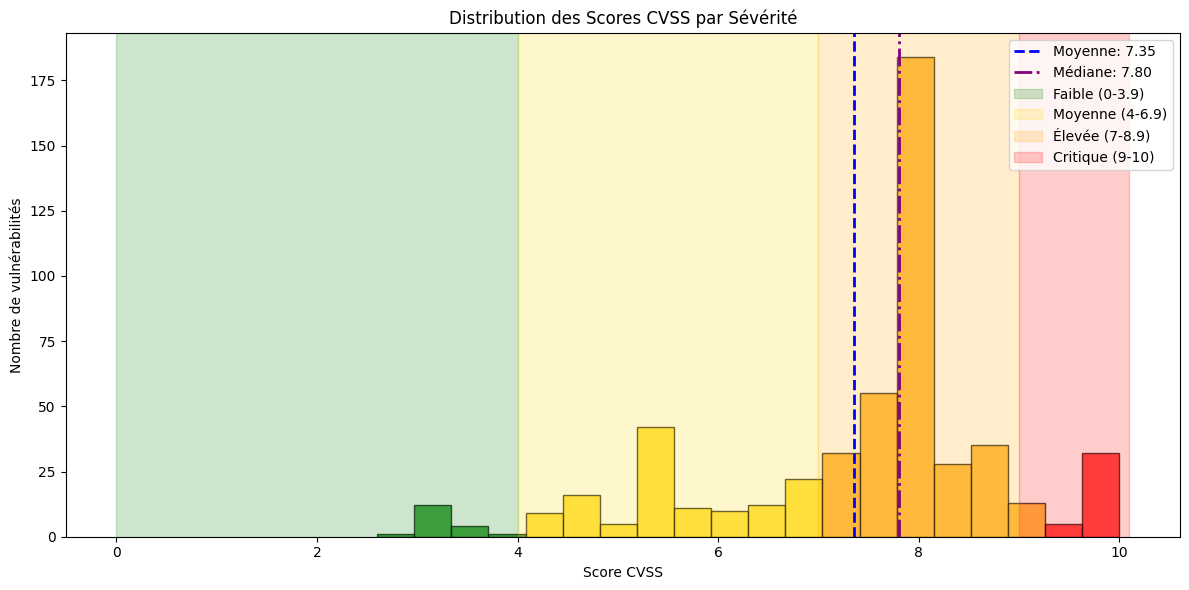

Nombre de valeurs disponibles: 529/1282 (41.3%)
Moyenne: 7.35
Médiane: 7.80
Écart-type: 1.46
Minimum: 2.60
Maximum: 10.00


Analyse des résultats

Sur les 529 CVE disposant d'un score CVSS (41.3% du total), 
la répartition par sévérité montre une concentration
dans les hautes gravités :

Critique (9-10)  :  50 CVE (9.5%)
Élevée (7-8.9)   : 353 CVE (66.7%)  <- majorité écrasante
Moyenne (4-6.9)  : 108 CVE (20.4%)
Faible (0-3.9)   :  18 CVE (3.4%)

La moyenne (7.35) et la médiane (7.80) sont toutes deux
situées dans la tranche "Élevée", ce qui veut dire que les
vulnérabilités sont plutôt sévères. L'écart-type relativement 
faible (1.46) montre que la distribution se ressèrre autour 
de cette zone 7-8, avec un pic visible juste avant le score 8

Cela veut dire que les bulletins ANSSI ne couvrent pas
l'ensemble du spectre de gravité, mais se concentrent
sur des vulnérabilités jugées préoccupantes. Plus de la 
moitié des CVE n'ont pas encore de score attribué par 
MITRE au moment de l'extra

In [6]:
#TOUJOURS ETAPE 5 - Visualisation -----------------------------------------------

#Histogramme des scores CVSS avec couleurs par sévérité

import matplotlib.pyplot as plt

cvss_clean = df[df['CVSS Score'].notna()]['CVSS Score']                         #Pour garder que les valeurs non null


def get_color(score):
    if score < 4.0:
        return 'green'
    elif score < 7.0:
        return 'gold'
    elif score < 9.0:
        return 'orange'
    else:
        return 'red'

#Historigramme = .hist
fig, ax = plt.subplots(figsize=(12, 6))                                         #fig = l'onglet, axe = la où ce sera dessiné, figsize = 12 pouces x 6 pouces

n, bins, patches = ax.hist(cvss_clean, bins=20, edgecolor='black', alpha=0.7)   # n = nb vulnérabilités pour chaque interval, bins = les barres sur l'axe X, patches = couleurs
                                                                                #Ici on prend les données = cvss_clean, 20 intervalles (bars) = bins, - , alpha = transparence



for patch, left_edge in zip(patches, bins[:-1]):                                #zip = créer une liste de tuples avec [(patches[0], bins[0]), ([1], [1]), ...]
    if left_edge < 4.0:
        patch.set_facecolor('green')                                            #Si la barre commence avant 4
    elif left_edge < 7.0:
        patch.set_facecolor('gold')                                             #" entre 4 et 7
    elif left_edge < 9.0:
        patch.set_facecolor('orange')                                           #" entre 7 et 9
    else:
        patch.set_facecolor('red')                                              #au delà



#Lignes verticales pour la moyenne et la médiane avec axvline : Axe X + Vertical + line (ligne verticale sur l'axe X)
ax.axvline(x=cvss_clean.mean(), color='blue', linestyle='--', linewidth=2, label=f'Moyenne: {cvss_clean.mean():.2f}')
ax.axvline(x=cvss_clean.median(), color='purple', linestyle='-.', linewidth=2, label=f'Médiane: {cvss_clean.median():.2f}')

#axvspan = Axe X - Vertical SPAN (étendue verticale)
ax.axvspan(0, 4, alpha=0.2, color='green', label='Faible (0-3.9)')
ax.axvspan(4, 7, alpha=0.2, color='gold', label='Moyenne (4-6.9)')
ax.axvspan(7, 9, alpha=0.2, color='orange', label='Élevée (7-8.9)')
ax.axvspan(9, 10.1, alpha=0.2, color='red', label='Critique (9-10)')


ax.set_xlabel('Score CVSS')
ax.set_ylabel('Nombre de vulnérabilités')
ax.set_title('Distribution des Scores CVSS par Sévérité')
ax.legend(loc='upper right')


plt.tight_layout()
plt.show()

print(f"Nombre de valeurs disponibles: {len(cvss_clean)}/{len(df)} ({len(cvss_clean)/len(df)*100:.1f}%)")
print(f"Moyenne: {cvss_clean.mean():.2f}")
print(f"Médiane: {cvss_clean.median():.2f}")
print(f"Écart-type: {cvss_clean.std():.2f}")
print(f"Minimum: {cvss_clean.min():.2f}")
print(f"Maximum: {cvss_clean.max():.2f}")



print("\n\nAnalyse des résultats")
print(f"""
Sur les 529 CVE disposant d'un score CVSS (41.3% du total), 
la répartition par sévérité montre une concentration
dans les hautes gravités :

Critique (9-10)  :  50 CVE (9.5%)
Élevée (7-8.9)   : 353 CVE (66.7%)  <- majorité écrasante
Moyenne (4-6.9)  : 108 CVE (20.4%)
Faible (0-3.9)   :  18 CVE (3.4%)

La moyenne (7.35) et la médiane (7.80) sont toutes deux
situées dans la tranche "Élevée", ce qui veut dire que les
vulnérabilités sont plutôt sévères. L'écart-type relativement 
faible (1.46) montre que la distribution se ressèrre autour 
de cette zone 7-8, avec un pic visible juste avant le score 8

Cela veut dire que les bulletins ANSSI ne couvrent pas
l'ensemble du spectre de gravité, mais se concentrent
sur des vulnérabilités jugées préoccupantes. Plus de la 
moitié des CVE n'ont pas encore de score attribué par 
MITRE au moment de l'extraction
""")

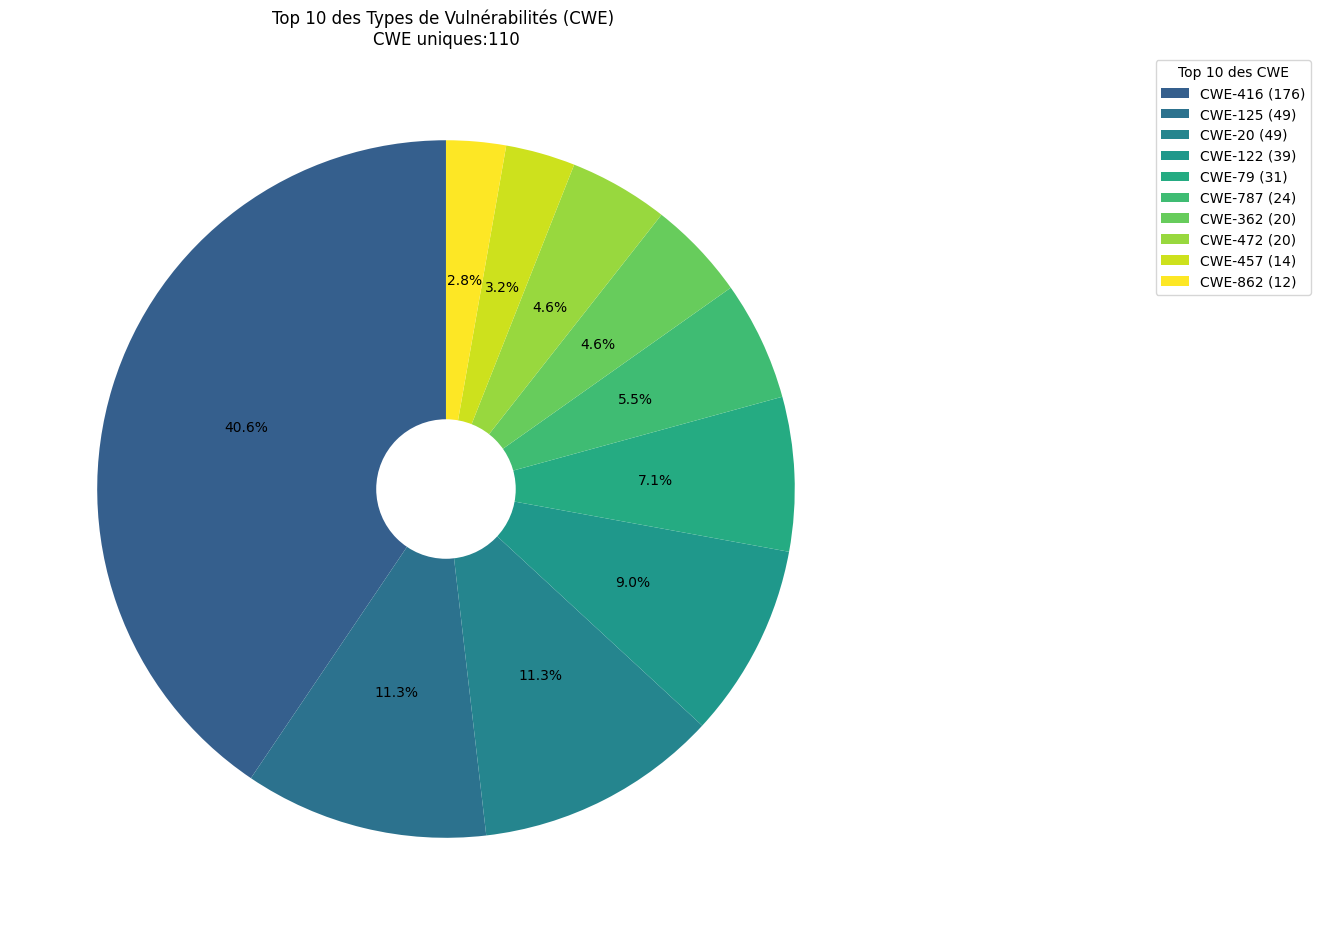

Nombre total de CVE avec CWE: 718/1282
Nombre de CWE uniques: 110

Top 5 des CWE:
   1. CWE-416: 176 occurrences (24.5%)
   2. CWE-125: 49 occurrences (6.8%)
   3. CWE-20: 49 occurrences (6.8%)
   4. CWE-122: 39 occurrences (5.4%)
   5. CWE-79: 31 occurrences (4.3%)


Analyse des résultats

718 CVE sur 1282 (56%) possèdent une classification CWE,
répartie sur 110 catégories différentes de failles :

CWE-416 (Use After Free)         : 176 occ. (24.5% sur tous le csv)
CWE-125 (Out-of-bounds Read)     :  49 occ. (6.8%)
CWE-20  (Improper Input Valid.)  :  49 occ. (6.8%)
CWE-122 (Heap-based Overflow)    :  39 occ. (5.4%)
CWE-79  (XSS)                    :  31 occ. (4.3%)

1 vulnérabilité sur 4 est une faille CWE-416, 
La présence de Microsoft Office est donc plutôt 
normal puisqu'il y a de nombreuses failles mémoire
Use-After-Free dans les composants Office/Win32K

Si on additionne les 5 premières catégories ont obtient environ 48% 
des CVE classifiées, le reste (52%) est éparpillé sur plus

In [7]:
#Diagramme circulaire des types CWE
import matplotlib.pyplot as plt
import numpy as np

cwe_counts = df[df['CWE'] != 'Non disponible']['CWE'].value_counts().head(10)           #Compter les occurrences de chaque CWE


cwe_labels = []
for cwe, count in zip(cwe_counts.index, cwe_counts.values):                             #Zip = créer une liste de tuples avec [(cwe_counts.index[0], cwe_counts.values[0]), ([1], [1]), ...]
    if len(cwe) > 25:                                                                   #Afficher CWE-ID et le nombre
        cwe_labels.append(f"{cwe}\n({count})")
    else:
        cwe_labels.append(f"{cwe} ({count})")



colors = plt.cm.viridis(np.linspace(0.3, 1, len(cwe_counts)))                           #Palette un peu cute ^w^ = dégradé de couleurs (bleu → vert → jaune)


fig, ax = plt.subplots(figsize=(12, 10))                                                #12 pouces x 10 pouces


wedges, texts, autotexts = ax.pie(                                                      #.pie = camember, wedges = nb parts dans le camember,texts = étiquettes, autotexts = poucentages
    cwe_counts.values,                                                                  #Taille de chaque part
    labels=None,                                                                        #Pas de labels directement sur le pie -> sur le côté
    autopct='%1.1f%%',                                                                  #Format des pourcentages 
    startangle=90,                                                                      #Commencer à 90° (en haut)
    colors=colors
)


ax.legend(wedges, cwe_labels, title="Top 10 des CWE", bbox_to_anchor=(1, 0, 0.5, 1))

centre_circle = plt.Circle((0, 0), 0.20, fc='white', linewidth=1.25)                    #C'est plus joli comme ça
fig.gca().add_artist(centre_circle)


total_cwe_types = df[df['CWE'] != 'Non disponible']['CWE'].nunique()
total_cve_with_cwe = len(df[df['CWE'] != 'Non disponible'])

ax.set_title(f'Top 10 des Types de Vulnérabilités (CWE) \nCWE uniques:{total_cwe_types}')

plt.tight_layout()
plt.show()


print(f"Nombre total de CVE avec CWE: {len(df[df['CWE'] != 'Non disponible'])}/{len(df)}")
print(f"Nombre de CWE uniques: {df[df['CWE'] != 'Non disponible']['CWE'].nunique()}")
print("\nTop 5 des CWE:")
for i, (cwe, count) in enumerate(cwe_counts.head(5).items(), 1):
    percentage = count / len(df[df['CWE'] != 'Non disponible']) * 100
    print(f"   {i}. {cwe}: {count} occurrences ({percentage:.1f}%)")


print("\n\nAnalyse des résultats")
print(f"""
718 CVE sur 1282 (56%) possèdent une classification CWE,
répartie sur 110 catégories différentes de failles :

CWE-416 (Use After Free)         : 176 occ. (24.5% sur tous le csv)
CWE-125 (Out-of-bounds Read)     :  49 occ. (6.8%)
CWE-20  (Improper Input Valid.)  :  49 occ. (6.8%)
CWE-122 (Heap-based Overflow)    :  39 occ. (5.4%)
CWE-79  (XSS)                    :  31 occ. (4.3%)

1 vulnérabilité sur 4 est une faille CWE-416, 
La présence de Microsoft Office est donc plutôt 
normal puisqu'il y a de nombreuses failles mémoire
Use-After-Free dans les composants Office/Win32K

Si on additionne les 5 premières catégories ont obtient environ 48% 
des CVE classifiées, le reste (52%) est éparpillé sur plus de
100 types différents donc beaucoup de vecteurs d'attaque mineurs

Les failles mémoire (Use-After-Free, buffer overflow, out-of-bounds) sont beaucoup plus
attaquées, donc plus d'attention devrait être porter sur les produits manipulant de la 
mémoire native (navigateurs, suites bureautiques, parsers)
""")

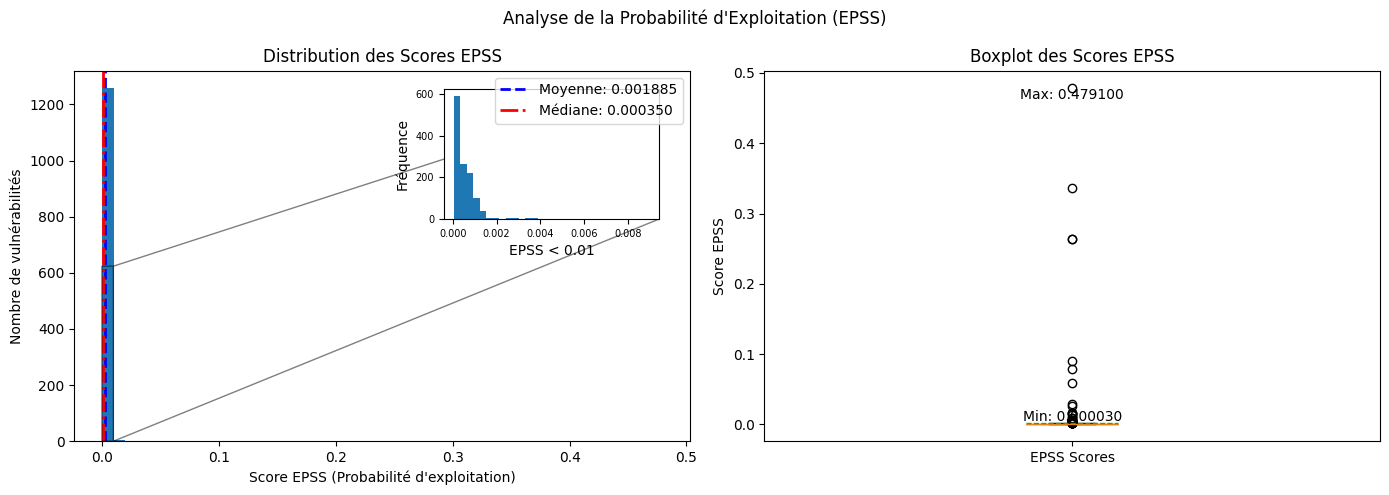

Nombre de valeurs disponibles: 1270/1282 (99.1%)
Moyenne: 0.001885
Médiane: 0.000350
Écart-type: 0.019819
Minimum: 0.000030
Maximum: 0.479100
90ème percentile: 0.001152
95ème percentile: 0.001428

Vulnérabilités avec EPSS > 0.1 (haut risque): 4
   Soit 0.31% du total


Analyse des résultats

99.1% des CVE (1270/1282) disposent d'un score EPSS,
(soit beaucoup plus que les scores CVSS)

Moyenne          : 0.001885 (0.19%)
Médiane          : 0.000350 (0.035%)
Écart-type       : 0.019819
Minimum          : 0.000030
Maximum          : 0.479100
90e percentile   : 0.001152
95e percentile   : 0.001428

La distribution est très asymétrique,
la quasi-totalité des vulnérabilités ont une probabilité
d'exploitation quasi nulle (médiane ~0.035%), mais il y aussi 
quelques valeurs extrêmes qui vont jusqu'à 47.9%

Seulement 4 vulnérabilités (0.31% du total) dépassent un
score EPSS de 0.1, ce qui les place dans une catégorie de
risque "haute priorité d'exploitation réelle"

La grande majorité des CVE o

In [8]:
#Courbe de distribution des scores EPSS

import matplotlib.pyplot as plt

epss_clean = df[df['EPSS Score'].notna()]['EPSS Score']                                             #Filtrer les valeurs non nulles


fig, axes = plt.subplots(1, 2, figsize=(14, 5))                                                     #Créer une fig avec deux subplot

#Histogramme de distribution
n, bins, patches = axes[0].hist(epss_clean, bins=50)
axes[0].set_xlabel('Score EPSS (Probabilité d\'exploitation)')
axes[0].set_ylabel('Nombre de vulnérabilités')
axes[0].set_title('Distribution des Scores EPSS')

#Ligne moyenne et médiane
axes[0].axvline(x=epss_clean.mean(), color='blue', linestyle='--', linewidth=2, label=f'Moyenne: {epss_clean.mean():.6f}')
axes[0].axvline(x=epss_clean.median(), color='red', linestyle='-.', linewidth=2, label=f'Médiane: {epss_clean.median():.6f}')
axes[0].legend(loc='upper right')

#Zoom sur la zone 0 - 600
inset_ax = axes[0].inset_axes([0.6, 0.6, 0.35, 0.35])
epss_low = epss_clean[epss_clean < 0.01]
inset_ax.hist(epss_low, bins=30)
inset_ax.set_xlabel('EPSS < 0.01')
inset_ax.set_ylabel('Fréquence')
inset_ax.tick_params(labelsize=7)
axes[0].indicate_inset_zoom(inset_ax, edgecolor="black")




#Boxplot
boxplot_data = [epss_clean]
bp = axes[1].boxplot(boxplot_data, vert=True, patch_artist=True, showmeans=True, meanline=True)
bp['boxes'][0].set_facecolor('teal')
bp['boxes'][0].set_alpha(0.7)
axes[1].set_ylabel('Score EPSS')
axes[1].set_title('Boxplot des Scores EPSS')
axes[1].set_xticklabels(['EPSS Scores'])

#Annotation Boxplot
axes[1].text(1, epss_clean.min(), f'Min: {epss_clean.min():.6f}', ha='center', va='bottom')
axes[1].text(1, epss_clean.max(), f'Max: {epss_clean.max():.6f}', ha='center', va='top')

plt.suptitle('Analyse de la Probabilité d\'Exploitation (EPSS)')
plt.tight_layout()
plt.show()




print(f"Nombre de valeurs disponibles: {len(epss_clean)}/{len(df)} ({len(epss_clean)/len(df)*100:.1f}%)")
print(f"Moyenne: {epss_clean.mean():.6f}")
print(f"Médiane: {epss_clean.median():.6f}")
print(f"Écart-type: {epss_clean.std():.6f}")
print(f"Minimum: {epss_clean.min():.6f}")
print(f"Maximum: {epss_clean.max():.6f}")
print(f"90ème percentile: {epss_clean.quantile(0.9):.6f}")
print(f"95ème percentile: {epss_clean.quantile(0.95):.6f}")




# Analyse des vulnérabilités à haut risque EPSS
high_epss = epss_clean[epss_clean > 0.1]
if len(high_epss) > 0:
    print(f"\nVulnérabilités avec EPSS > 0.1 (haut risque): {len(high_epss)}")
    print(f"   Soit {len(high_epss)/len(epss_clean)*100:.2f}% du total")
else:
    print("\nAucune vulnérabilité avec EPSS > 0.1")


print("\n\nAnalyse des résultats")
print(f"""
99.1% des CVE (1270/1282) disposent d'un score EPSS,
(soit beaucoup plus que les scores CVSS)

Moyenne          : 0.001885 (0.19%)
Médiane          : 0.000350 (0.035%)
Écart-type       : 0.019819
Minimum          : 0.000030
Maximum          : 0.479100
90e percentile   : 0.001152
95e percentile   : 0.001428

La distribution est très asymétrique,
la quasi-totalité des vulnérabilités ont une probabilité
d'exploitation quasi nulle (médiane ~0.035%), mais il y aussi 
quelques valeurs extrêmes qui vont jusqu'à 47.9%

Seulement 4 vulnérabilités (0.31% du total) dépassent un
score EPSS de 0.1, ce qui les place dans une catégorie de
risque "haute priorité d'exploitation réelle"

La grande majorité des CVE ont très peu de chance d'être 
exploitées à court terme. La priorisation doit don être sur les scores 
EPSS plus élevés, indépendamment de leur score CVSS brut (le CVSS mesure 
la gravité potentielle / l'EPSS la probabilité réelle d'exploitation)
""")

 1. Microsoft            :  460 occurrences (35.88%)
 2. Linux                :  330 occurrences (25.74%)
 3. Palo Alto            :  253 occurrences (19.73%)
 4. Splunk               :   43 occurrences ( 3.35%)
 5. Spring               :   29 occurrences ( 2.26%)
 6. Google               :   28 occurrences ( 2.18%)
 7. Adobe                :   27 occurrences ( 2.11%)
 8. OpenSSL              :   18 occurrences ( 1.40%)
 9. MongoDB              :   15 occurrences ( 1.17%)
10. SAP                  :   15 occurrences ( 1.17%)
11. GitLab               :   12 occurrences ( 0.94%)
12. IBM                  :   12 occurrences ( 0.94%)
13. Typo3                :   10 occurrences ( 0.78%)
14. Xen                  :    5 occurrences ( 0.39%)
15. NetApp               :    4 occurrences ( 0.31%)


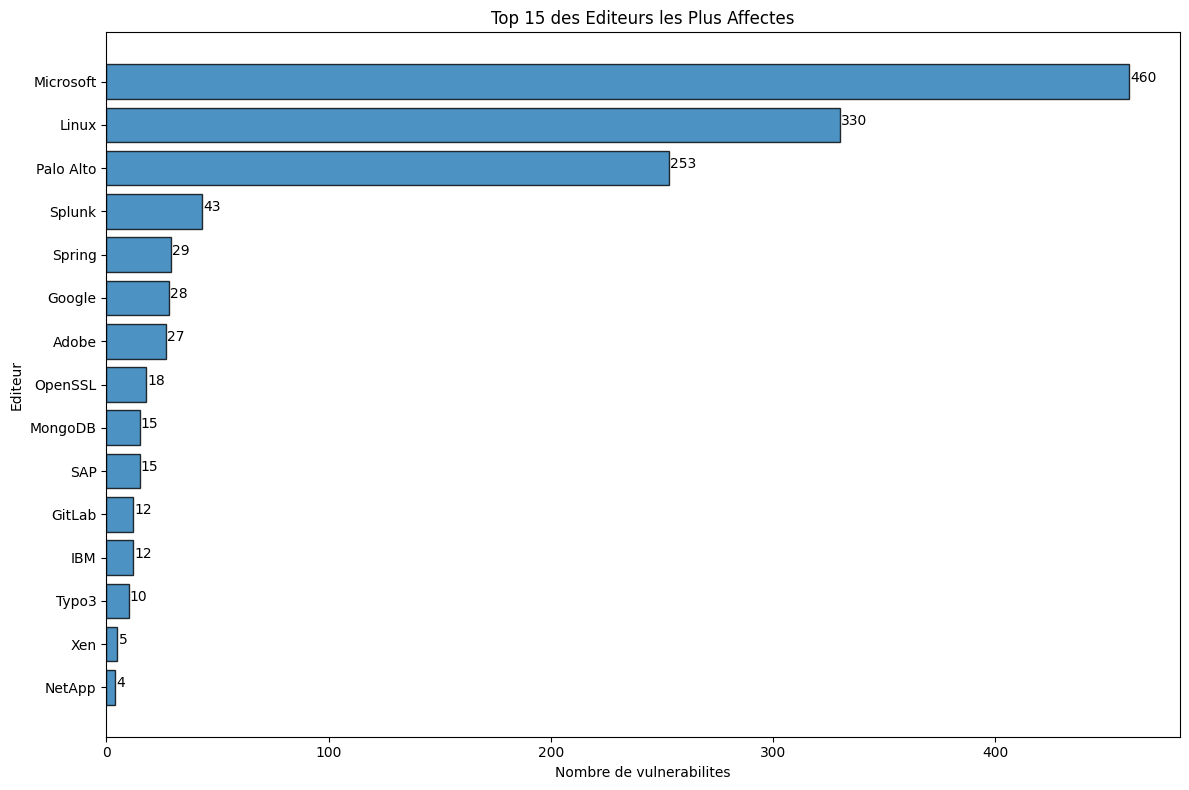

Nombre total d'editeurs distincts: 28
Top 3 represente: 81.4% des vulnerabilites
Nombre de vulnerabilites sans editeur identifie (Autre): 0


In [9]:
#Extraction des editeurs + classement

import pandas as pd
import matplotlib.pyplot as plt
import re


def extract_vendor_from_title(title):                                                                           #extraire l'editeur à partir du titre du bulletin
    title_lower = str(title).lower()
    
    #Liste des editeurs connus
    vendors = {
        'Microsoft': ['microsoft', 'windows', 'office', 'azure', '.net', 'exchange', 'edge'],
        'Cisco': ['cisco', 'catalyst', 'sd-wan'],
        'SAP': ['sap', 'business objects', 'fiori'],
        'Adobe': ['adobe', 'acrobat', 'reader', 'flash', 'photoshop'],
        'Google': ['google', 'chrome', 'android'],
        'Apple': ['apple', 'ios', 'macos', 'ipados', 'watchos', 'tvos'],
        'Linux': ['linux', 'kernel'],
        'Red Hat': ['red hat', 'rhel'],
        'Ubuntu': ['ubuntu', 'canonical'],
        'SUSE': ['suse'],
        'Oracle': ['oracle', 'mysql', 'java', 'peoplesoft'],
        'IBM': ['ibm'],
        'VMware': ['vmware', 'vcenter', 'esxi'],
        'Dell': ['dell', 'emc'],
        'HP': ['hp', 'hewlett packard'],
        'Intel': ['intel'],
        'AMD': ['amd'],
        'NVIDIA': ['nvidia'],
        'Samsung': ['samsung'],
        'Siemens': ['siemens'],
        'Schneider': ['schneider', 'ecostruxure'],
        'Fortinet': ['fortinet', 'fortigate'],
        'Ivanti': ['ivanti'],
        'MongoDB': ['mongodb'],
        'PostgreSQL': ['postgresql'],
        'Apache': ['apache', 'http server', 'tomcat'],
        'Nginx': ['nginx'],
        'OpenSSL': ['openssl'],
        'Spring': ['spring', 'spring boot', 'spring framework'],
        'Palo Alto': ['palo alto', 'pan-os'],
        'Splunk': ['splunk'],
        'GitLab': ['gitlab'],
        'NetApp': ['netapp'],
        'Moxa': ['moxa'],
        'Xen': ['xen'],
        'Typo3': ['typo3'],
        'Stormshield': ['stormshield'],
        'FreeBSD': ['freebsd'],
        'Veeam': ['veeam'],
        'Traefik': ['traefik'],
        'LibreNMS': ['librenms'],
        'F5': ['f5', 'big-ip'],
        'Juniper': ['juniper'],
        'Huawei': ['huawei'],
        'Zyxel': ['zyxel'],
        'Qualcomm': ['qualcomm'],
        'WordPress': ['wordpress'],
        'Drupal': ['drupal'],
        'Joomla': ['joomla']
    }
    
    for vendor, keywords in vendors.items():
        for keyword in keywords:
            if keyword in title_lower:
                return vendor
    return 'Autre'


df['Editeur'] = df['Titre'].apply(extract_vendor_from_title)                                                    #Appliquer l'extraction


vendor_counts = df['Editeur'].value_counts()                                                                    #compter les occurrences par editeur
top_vendors = vendor_counts.head(15)


for i, (vendor, count) in enumerate(top_vendors.items(), 1):
    percentage = count / len(df) * 100
    print(f"{i:2d}. {vendor:20s} : {count:4d} occurrences ({percentage:5.2f}%)")


fig, ax = plt.subplots(figsize=(12, 8))                                                                         #Barres horizontales 12 pouces x 8 pouces

bars = ax.barh(range(len(top_vendors)), top_vendors.values, edgecolor='black', alpha=0.8)                       #.barh = bar horizontal, range(len(top_vendors)) = position des barres sur l'axe Y, top_vendors.values = taille des barres

ax.set_yticks(range(len(top_vendors)))
ax.set_yticklabels(top_vendors.index)
ax.set_xlabel('Nombre de vulnerabilites')
ax.set_ylabel('Editeur')
ax.set_title('Top 15 des Editeurs les Plus Affectes')
ax.invert_yaxis()


for i, (bar, val) in enumerate(zip(bars, top_vendors.values)):                                                  # enumerate = pour avoir un compteur i
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, str(val))

plt.tight_layout()
plt.show()



print(f"Nombre total d'editeurs distincts: {df['Editeur'].nunique()}")
print(f"Top 3 represente: {(top_vendors.iloc[:3].sum() / len(df) * 100):.1f}% des vulnerabilites")
print(f"Nombre de vulnerabilites sans editeur identifie (Autre): {vendor_counts.get('Autre', 0)}")

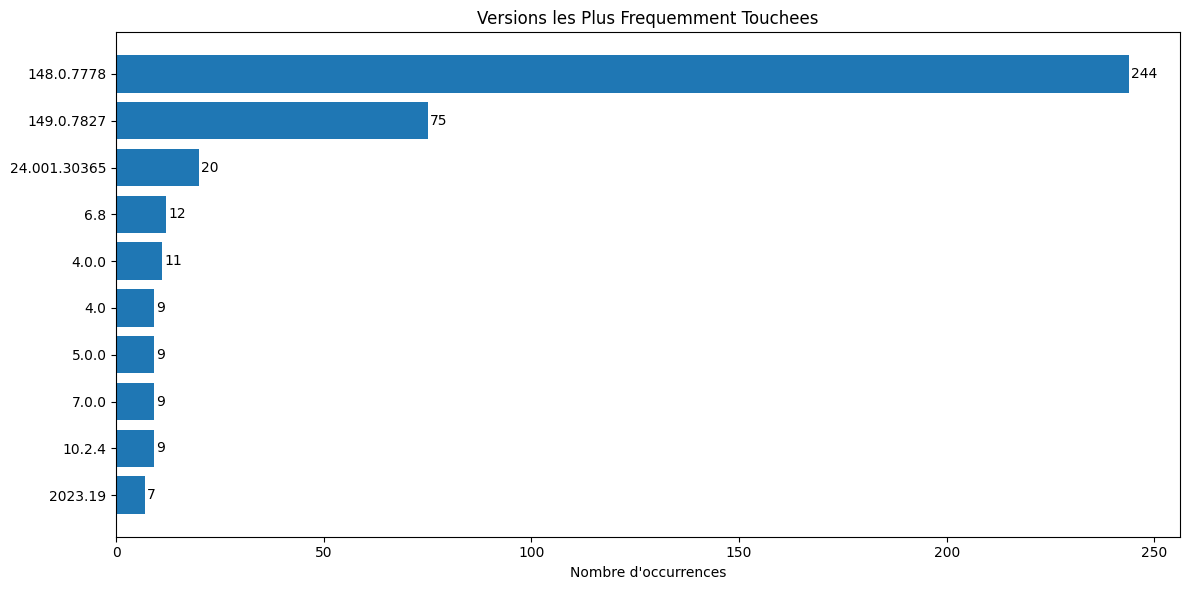



Analyse des résultats

1. 148.0.7778    : 244 occurrences
2. 149.0.7827    :  75 occurrences
3. 24.001.30365  :  20 occurrences
4. 6.8           :  12 occurrences
5. 4.0.0         :  11 occurrences
... puis un palier autour de 7-9 occurrences pour le
    reste du top 10

Si on les additionne, on a 319 occurrences pour les versions 148.0.7778 
et 149.0.7827 (probablement des versions de navigateur de type Chromium/Edge, 
vu leur format de numérotation)

Cela veut dire que les versions de navigateurs sont très souvent touchées par 
des vulnérabilités et qu'il est important de maintenir ces logiciels à jour 
pour réduire le risque d'exploitation



In [10]:
#Versions les plus frequemment touchees

import matplotlib.pyplot as plt
import re

def extract_version(title):
    patterns = [r'(\d+\.\d+(?:\.\d+)?)', r'R\d+(?:\.\d+)?', r'v\d+(?:\.\d+)+', r'version\s+(\d+\.\d+)'] #patterns pour extraire tous les types de versions
    for pattern in patterns:
        match = re.search(pattern, str(title).lower())                                                  #chercher le pattern dans le titre en minuscule
        if match:
            return match.group(1)
    return None

df['Version'] = df['Description'].apply(extract_version)                                                #apply = appliquer la fonction extract_version sur la colonne Description pour extraire les versions
df['Version'] = df['Version'].fillna(df['Titre'].apply(extract_version))

version_counts = df[df['Version'].notna()]['Version'].value_counts().head(10)


if len(version_counts) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    bars = ax.barh(range(len(version_counts)), version_counts.values)
    
    ax.set_yticks(range(len(version_counts)))
    ax.set_yticklabels(version_counts.index)
    ax.set_xlabel('Nombre d\'occurrences')
    ax.set_title('Versions les Plus Frequemment Touchees')
    ax.invert_yaxis()
    
    for i, (bar, val) in enumerate(zip(bars, version_counts.values)):                                   #enumerate = pour avoir un compteur i, zip = pour parcourir les deux listes en parallèle
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, str(val), va='center')
    
    plt.tight_layout()
    plt.show()
else:
    print("Aucune version detectee dans les donnees")


print("\n\nAnalyse des résultats")

print(f"""
1. 148.0.7778    : 244 occurrences
2. 149.0.7827    :  75 occurrences
3. 24.001.30365  :  20 occurrences
4. 6.8           :  12 occurrences
5. 4.0.0         :  11 occurrences
... puis un palier autour de 7-9 occurrences pour le
    reste du top 10

Si on les additionne, on a 319 occurrences pour les versions 148.0.7778 
et 149.0.7827 (probablement des versions de navigateur de type Chromium/Edge, 
vu leur format de numérotation)

Cela veut dire que les versions de navigateurs sont très souvent touchées par 
des vulnérabilités et qu'il est important de maintenir ces logiciels à jour 
pour réduire le risque d'exploitation
""")

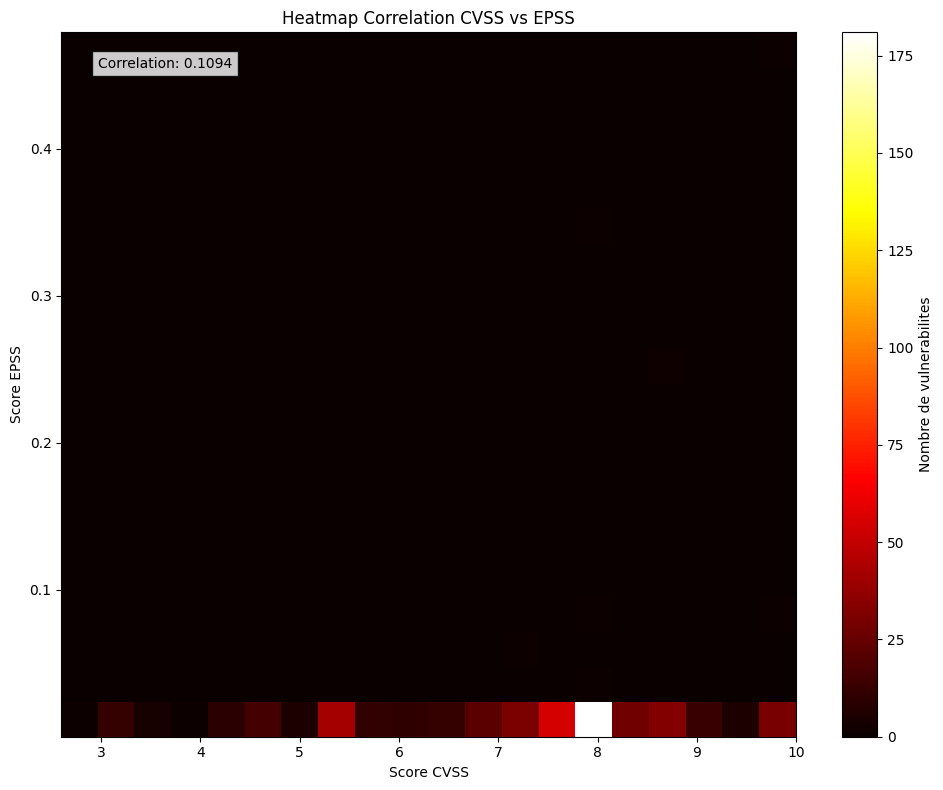



Analyse des résultats

Corrélation calculée : 0.1094

Cette corrélation est très faible, quasi nulle, ce qui
indique qu'il n'existe pas de relation linéaire forte
entre la gravité théorique (CVSS) et la probabilité
d'exploitation réelle (EPSS) sur ce jeu de données

La heatmap montre une concentration massive des
vulnérabilités dans la zone CVSS 7-8 / EPSS proche de 0
(cellule blanche très dense), confirmant que la majorité
des CVE à fort impact potentiel restent peu exploitées
en pratique

Quelques points isolés à EPSS élevé (0.25-0.48) se situent
sur une plage de CVSS variée, sans tendance claire vers
les scores les plus élevés.

Un score CVSS élevé ne garantit pas une exploitation et inversement.
Le CVSS pour évaluer l'impact potentiel, l'EPSS pour évaluer l'urgence 
réelle. Une vulnérabilité CVSS 9+ avec EPSS proche de 0 peut être 
traitée avec moins d'urgence qu'une vulnérabilité CVSS 6 avec EPSS > 0.1.



In [11]:
#Heatmap de correlation CVSS vs EPSS

import matplotlib.pyplot as plt
import numpy as np

corr_df = df[['CVSS Score', 'EPSS Score']].dropna()


#.historogram2d = créer une matrice 2d, bins = nombre d'intervalles pour chaque variable
heatmap_data, xedges, yedges = np.histogram2d(corr_df['CVSS Score'], corr_df['EPSS Score'], bins=20)



fig, ax = plt.subplots(figsize=(10, 8))

#imshow = afficher la matrice 2d, origin = 'lower' pour avoir les axes dans le bon sens, aspect = cases soient carrées, extent = axes soient aux bonnes échelles, cmap = 'hot' pour une palette de couleurs chaudes, interpolation = ne pas lisser les couleurs
im = ax.imshow(heatmap_data.T, origin='lower', aspect='auto', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap='hot', interpolation='nearest')

ax.set_xlabel('Score CVSS')
ax.set_ylabel('Score EPSS')
ax.set_title('Heatmap Correlation CVSS vs EPSS')
plt.colorbar(im, ax=ax, label='Nombre de vulnerabilites')

correlation = corr_df['CVSS Score'].corr(corr_df['EPSS Score'])
#.text = ajouter du texte sur le graphique, transform = position texte par rapport à l'axe, bbox = mettre le texte dans une boîte
ax.text(0.05, 0.95, f'Correlation: {correlation:.4f}', transform = ax.transAxes, bbox = dict(facecolor = 'white', alpha = 0.8))

plt.tight_layout()
plt.show()



print("\n\nAnalyse des résultats")
print(f"""
Corrélation calculée : 0.1094

Cette corrélation est très faible, quasi nulle, ce qui
indique qu'il n'existe pas de relation linéaire forte
entre la gravité théorique (CVSS) et la probabilité
d'exploitation réelle (EPSS) sur ce jeu de données

La heatmap montre une concentration massive des
vulnérabilités dans la zone CVSS 7-8 / EPSS proche de 0
(cellule blanche très dense), confirmant que la majorité
des CVE à fort impact potentiel restent peu exploitées
en pratique

Quelques points isolés à EPSS élevé (0.25-0.48) se situent
sur une plage de CVSS variée, sans tendance claire vers
les scores les plus élevés.

Un score CVSS élevé ne garantit pas une exploitation et inversement.
Le CVSS pour évaluer l'impact potentiel, l'EPSS pour évaluer l'urgence 
réelle. Une vulnérabilité CVSS 9+ avec EPSS proche de 0 peut être 
traitée avec moins d'urgence qu'une vulnérabilité CVSS 6 avec EPSS > 0.1.
""")

In [12]:
#Scatter plot CVSS vs EPSS (avec Plotly)
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

scatter_df = df[df['CVSS Score'].notna() & df['EPSS Score'].notna()].copy()

def get_severity_label(score):
    if score < 4.0:
        return 'Faible (0-3.9)'
    elif score < 7.0:
        return 'Moyenne (4-6.9)'
    elif score < 9.0:
        return 'Elevee (7-8.9)'
    else:
        return 'Critique (9-10)'

scatter_df['Severite'] = scatter_df['CVSS Score'].apply(get_severity_label)

print(f"Nombre de points pour le scatter plot: {len(scatter_df)}")

color_map = {
    'Critique (9-10)': 'red',
    'Elevee (7-8.9)': 'orange',
    'Moyenne (4-6.9)': 'gold',
    'Faible (0-3.9)': 'green'
}


fig = px.scatter(                                                                                   #px = plotly express
    scatter_df,                                                                                     #Données utilisées
    x='CVSS Score',                                                                                 #Score de gravité
    y='EPSS Score',                                                                                 #Probabilité d'exploitation
    color='Severite',
    color_discrete_map=color_map,
    hover_data=['CVE', 'CWE', 'Editeur', 'Type'],                                                   #Ce qu'on voit quand on survole un point
    title='Relation entre Gravite (CVSS) et Probabilite d\'Exploitation (EPSS)',
    labels={                                                                                        #Labels pour les axes
        'CVSS Score': 'Score CVSS (Gravite)',
        'EPSS Score': 'Score EPSS (Probabilite d\'exploitation)',               
        'Severite': 'Niveau de gravite'
    },
    trendline='ols'                                                                                 #Ordinary Least Squares (régression linéaire)
)


fig.update_layout(
    width=900,
    height=600,
    xaxis=dict(showgrid=True),
    yaxis=dict(showgrid=True)
)

fig.update_traces(
    marker=dict(size=10, opacity=0.7, line=dict(width=0.7, color='black'))
)

fig.show()





correlation = scatter_df['CVSS Score'].corr(scatter_df['EPSS Score'])                               #Calcul la corélation
print(f"\nCoefficient de correlation de Pearson entre CVSS et EPSS: {correlation:.4f}")



high_risk = scatter_df[(scatter_df['CVSS Score'] >= 7) & (scatter_df['EPSS Score'] > 0.01)]         #Sélectionne les vulnérabilités à haut risque
print(f"\nVulnerabilites a haut risque (CVSS >= 7 ET EPSS > 0.01): {len(high_risk)}")
if len(high_risk) > 0:
    print("\nCVE a risque prioritaire:")
    for _, row in high_risk.nlargest(5, 'EPSS Score').iterrows():
        print(f"  - {row['CVE']}: CVSS={row['CVSS Score']}, EPSS={row['EPSS Score']:.6f}, Editeur={row['Editeur']}")


print("\n\nAnalyse des résultats")
print(f"""
Coefficient de corrélation de Pearson : 0.1094

Cette corrélation quasi nulle confirme l'absence de lien
linéaire global entre gravité théorique (CVSS) et
probabilité réelle d'exploitation (EPSS). La grande
majorité des points sont écrasés près de EPSS=0, quel
que soit leur niveau de CVSS (catégories Faible, Moyenne,
Élevée, Critique confondues)

Mais, 12 vulnérabilités cumulent un CVSS élevé
(>= 7) ET un EPSS significatif (> 0.01), ce qui en fait
des cibles prioritaires de remédiation, on a :

CVE-2026-10520 : CVSS=10.0, EPSS=0.4791 (Ivanti)
CVE-2026-43500 : CVSS=7.8,  EPSS=0.3366 (Linux)
CVE-2026-43284 : CVSS=8.8,  EPSS=0.2634 (Linux)
CVE-2026-10523 : CVSS=9.9,  EPSS=0.0906 (Ivanti)
... (8 autres CVE dans la même zone)

Ces outliers concentrent l'impact potentiel maximal 
et un risque d'exploitation réel mesurable. Ils 
doivent être traités en priorité, contrairement à la 
masse des CVE critiques mais peu exploitées. On note aussi
que CVE-2026-43284 apparaît en double, probablement lié
à deux bulletins ANSSI différents référençant le même CVE
""")


Nombre de points pour le scatter plot: 529



Coefficient de correlation de Pearson entre CVSS et EPSS: 0.1094

Vulnerabilites a haut risque (CVSS >= 7 ET EPSS > 0.01): 12

CVE a risque prioritaire:
  - CVE-2026-10520: CVSS=10.0, EPSS=0.479100, Editeur=Ivanti
  - CVE-2026-43500: CVSS=7.8, EPSS=0.336580, Editeur=Linux
  - CVE-2026-43284: CVSS=8.8, EPSS=0.263370, Editeur=Linux
  - CVE-2026-43284: CVSS=8.8, EPSS=0.263370, Editeur=Linux
  - CVE-2026-10523: CVSS=9.9, EPSS=0.090610, Editeur=Ivanti


Analyse des résultats

Coefficient de corrélation de Pearson : 0.1094

Cette corrélation quasi nulle confirme l'absence de lien
linéaire global entre gravité théorique (CVSS) et
probabilité réelle d'exploitation (EPSS). La grande
majorité des points sont écrasés près de EPSS=0, quel
que soit leur niveau de CVSS (catégories Faible, Moyenne,
Élevée, Critique confondues)

Mais, 12 vulnérabilités cumulent un CVSS élevé
(>= 7) ET un EPSS significatif (> 0.01), ce qui en fait
des cibles prioritaires de remédiation, on a :

CVE-2026-10520 : CVSS=1

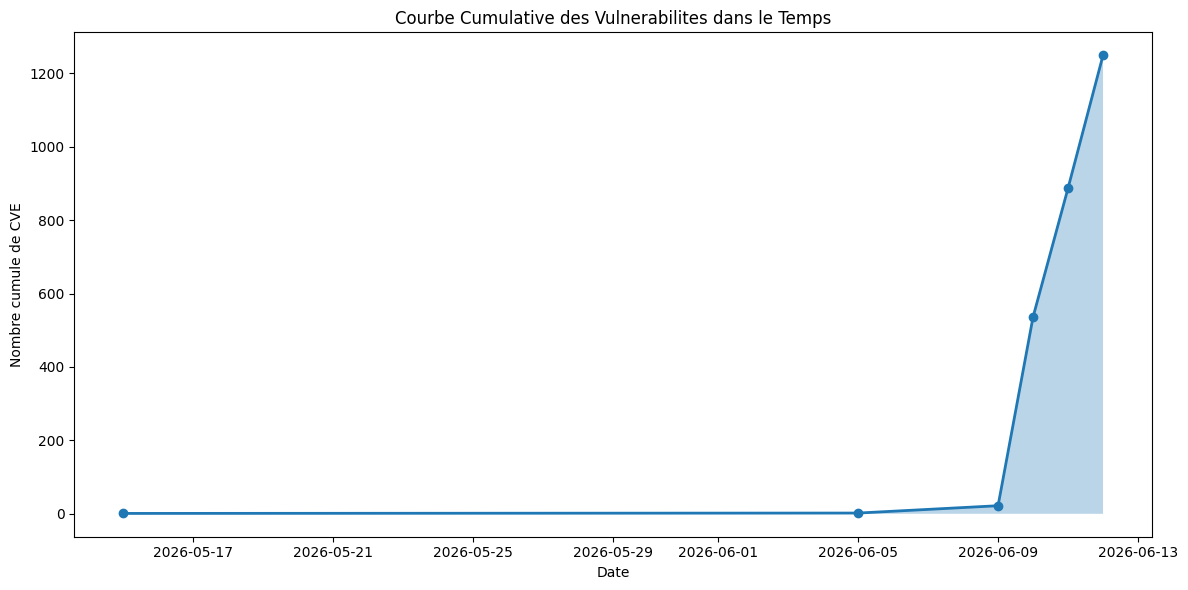

Total cumule de CVE uniques: 1249


In [13]:
#Courbe cumulative des vulnerabilites dans le temps

import matplotlib.pyplot as plt

daily_cves = df.groupby(df['Date'].dt.date)['CVE'].nunique().reset_index()
daily_cves.columns = ['Date', 'New_Unique_CVEs']
daily_cves['Cumulative_CVEs'] = daily_cves['New_Unique_CVEs'].cumsum()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(daily_cves['Date'], daily_cves['Cumulative_CVEs'], marker='o', linewidth=2, markersize=6)

ax.fill_between(daily_cves['Date'], daily_cves['Cumulative_CVEs'], alpha=0.3)

ax.set_xlabel('Date')
ax.set_ylabel('Nombre cumule de CVE')
ax.set_title('Courbe Cumulative des Vulnerabilites dans le Temps')


plt.tight_layout()
plt.show()

print(f"Total cumule de CVE uniques: {daily_cves['Cumulative_CVEs'].iloc[-1]}")

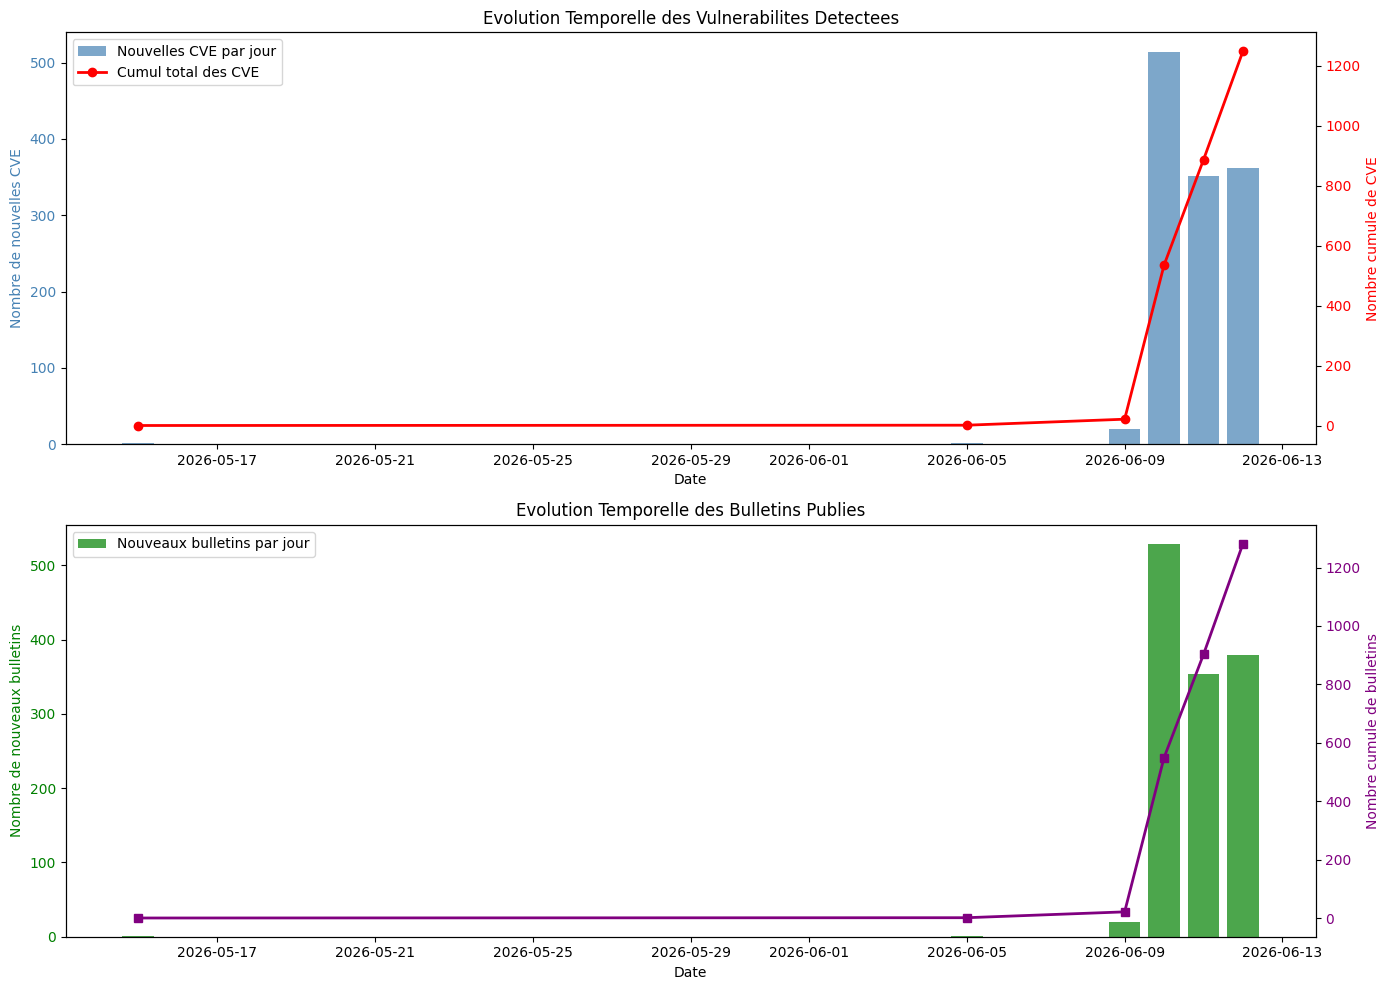

Periode d'analyse: du 2026-05-15 au 2026-06-12
Nombre total de jours: 6
Total CVE uniques sur la periode: 1249
Total bulletins sur la periode: 1282
Moyenne de CVE par jour: 208.2
Jour avec le plus de nouvelles CVE: 2026-06-10 (514 CVE)


Analyse des résultats

Période d'analyse : du 2026-05-15 au 2026-06-12 (6 jours
de publication effective)
Total CVE uniques sur la période : 1249
Total bulletins sur la période   : 1282
Moyenne de CVE par jour (sur les jours actifs) : 208.2

On voit sur le graphique qu'il y a une activité quasi 
nulle entre le 15 mai et le 5 juin, puis une grande explosion
à partir du 9-10 juin :

2026-06-09 :  ~20  nouveaux bulletins/CVE
2026-06-10 :  514  nouvelles CVE (pic)
2026-06-11 :  353  nouvelles CVE
2026-06-12 :  362  nouvelles CVE

La courbe cumulative passe de quasi 0 à plus de 1200 CVE
en seulement 4 jours, ce qui correspond à la publication
groupée des avis "Patch Tuesday" (Microsoft Office,
SAP, Fortinet, etc. publiés mi-juin 2026)

Il n'y a pas une expl

In [14]:
#Evolution temporelle cumulative des vulnerabilites

import matplotlib.pyplot as plt
import pandas as pd


#Vérifier que la colonne Date est bien en datetime
if not pd.api.types.is_datetime64_any_dtype(df['Date']):
    df['Date'] = pd.to_datetime(df['Date'], format='%a, %d %b %Y %H:%M:%S %z', errors='coerce')

#Grouper par jour (uniquement la date, sans l'heure)
daily_cves = df.groupby(df['Date'].dt.date)['CVE'].nunique().reset_index()
daily_cves.columns = ['Date', 'New_Unique_CVEs']
daily_cves['Cumulative_CVEs'] = daily_cves['New_Unique_CVEs'].cumsum()

#Compter également les bulletins par jour
daily_bulletins = df.groupby(df['Date'].dt.date).size().reset_index()
daily_bulletins.columns = ['Date', 'New_Bulletins']
daily_bulletins['Cumulative_Bulletins'] = daily_bulletins['New_Bulletins'].cumsum()



fig, axes = plt.subplots(2, 1, figsize=(14, 10))

#Nouvelles CVE par jour (barres) et cumul (ligne)
ax1 = axes[0]
bars = ax1.bar(daily_cves['Date'], daily_cves['New_Unique_CVEs'], alpha=0.7, label='Nouvelles CVE par jour', color='steelblue')

ax1.set_xlabel('Date')
ax1.set_ylabel('Nombre de nouvelles CVE', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_title('Evolution Temporelle des Vulnerabilites Detectees')

ax1_twin = ax1.twinx()
ax1_twin.plot(daily_cves['Date'], daily_cves['Cumulative_CVEs'], color='red', marker='o', linewidth=2, label='Cumul total des CVE')
ax1_twin.set_ylabel('Nombre cumule de CVE', color='red')
ax1_twin.tick_params(axis='y', labelcolor='red')


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)





#Nouveaux bulletins par jour (barres) et cumul (ligne)
ax2 = axes[1]
ax2.bar(daily_bulletins['Date'], daily_bulletins['New_Bulletins'], 
        alpha=0.7, label='Nouveaux bulletins par jour', color='green')

ax2.set_xlabel('Date')
ax2.set_ylabel('Nombre de nouveaux bulletins', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.set_title('Evolution Temporelle des Bulletins Publies')

ax2_twin = ax2.twinx()
ax2_twin.plot(daily_bulletins['Date'], daily_bulletins['Cumulative_Bulletins'], color='purple', marker='s', linewidth=2, label='Cumul total des bulletins')
ax2_twin.set_ylabel('Nombre cumule de bulletins', color='purple')
ax2_twin.tick_params(axis='y', labelcolor='purple')

ax2.legend(loc='upper left')


plt.tight_layout()
plt.show()



print(f"Periode d'analyse: du {daily_cves['Date'].min()} au {daily_cves['Date'].max()}")
print(f"Nombre total de jours: {len(daily_cves)}")
print(f"Total CVE uniques sur la periode: {daily_cves['Cumulative_CVEs'].iloc[-1]}")
print(f"Total bulletins sur la periode: {daily_bulletins['Cumulative_Bulletins'].iloc[-1]}")
print(f"Moyenne de CVE par jour: {daily_cves['New_Unique_CVEs'].mean():.1f}")
print(f"Jour avec le plus de nouvelles CVE: {daily_cves.loc[daily_cves['New_Unique_CVEs'].idxmax(), 'Date']} ({daily_cves['New_Unique_CVEs'].max()} CVE)")


print("\n\nAnalyse des résultats")
print(f"""
Période d'analyse : du 2026-05-15 au 2026-06-12 (6 jours
de publication effective)
Total CVE uniques sur la période : 1249
Total bulletins sur la période   : 1282
Moyenne de CVE par jour (sur les jours actifs) : 208.2

On voit sur le graphique qu'il y a une activité quasi 
nulle entre le 15 mai et le 5 juin, puis une grande explosion
à partir du 9-10 juin :

2026-06-09 :  ~20  nouveaux bulletins/CVE
2026-06-10 :  514  nouvelles CVE (pic)
2026-06-11 :  353  nouvelles CVE
2026-06-12 :  362  nouvelles CVE

La courbe cumulative passe de quasi 0 à plus de 1200 CVE
en seulement 4 jours, ce qui correspond à la publication
groupée des avis "Patch Tuesday" (Microsoft Office,
SAP, Fortinet, etc. publiés mi-juin 2026)

Il n'y a pas une explotation des failles soudaine en mai/juin
mais une augmentation du rythme de publication mensuel des éditeurs
majeurs (notamment Microsoft). Pour une analyse de tendance fiable, 
il faudrait disposer d'un historique plus long couvrant plusieurs 
cycles de Patch Tuesday donc plusieurs mois/années
""")

Microsoft           : 285 valeurs CVSS
Linux               : 122 valeurs CVSS
Adobe               :  27 valeurs CVSS
Spring              :  26 valeurs CVSS
Splunk              :  21 valeurs CVSS
SAP                 :  13 valeurs CVSS


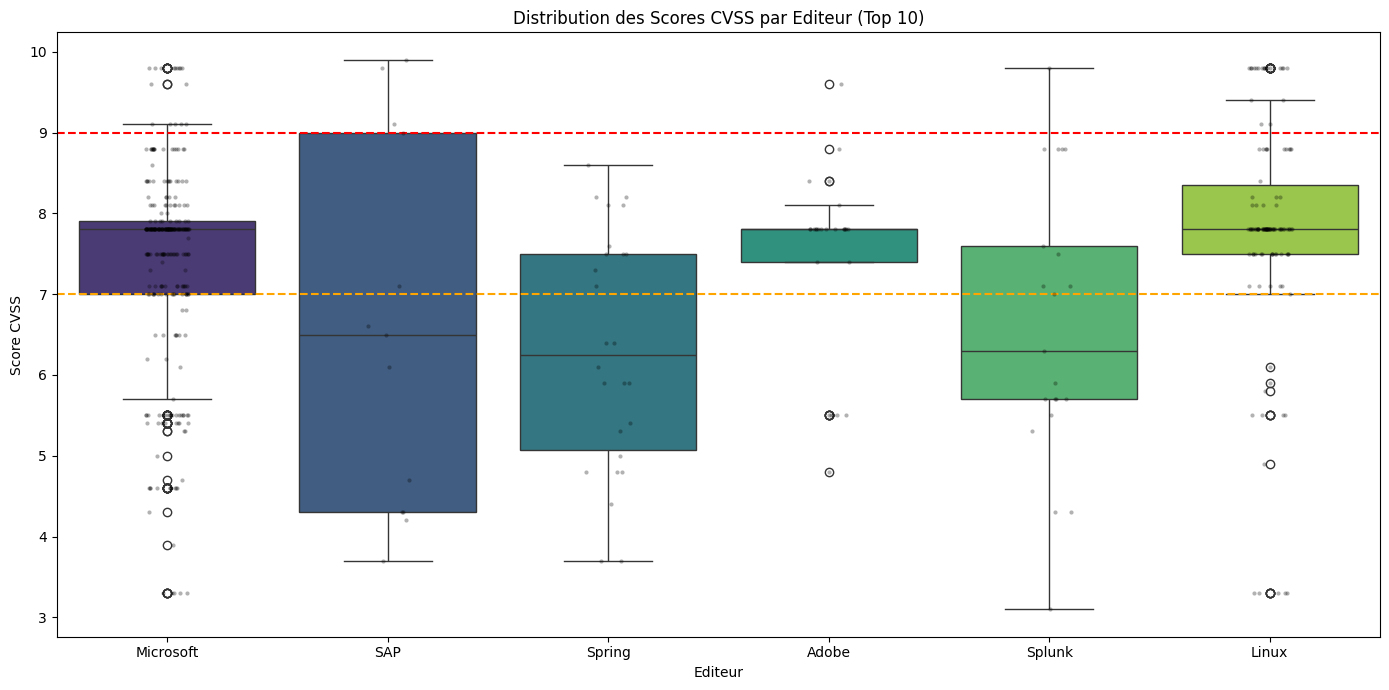


Microsoft:
Score CVSS moyen: 7.37
Score CVSS median: 7.80
Pourcentage de scores critiques (>=9): 5.6%
Pourcentage de scores eleves (>=7): 79.3%

Linux:
Score CVSS moyen: 7.81
Score CVSS median: 7.80
Pourcentage de scores critiques (>=9): 16.4%
Pourcentage de scores eleves (>=7): 89.3%

Splunk:
Score CVSS moyen: 6.61
Score CVSS median: 6.30
Pourcentage de scores critiques (>=9): 4.8%
Pourcentage de scores eleves (>=7): 47.6%

Spring:
Score CVSS moyen: 6.32
Score CVSS median: 6.25
Pourcentage de scores critiques (>=9): 0.0%
Pourcentage de scores eleves (>=7): 42.3%

Adobe:
Score CVSS moyen: 7.39
Score CVSS median: 7.80
Pourcentage de scores critiques (>=9): 3.7%
Pourcentage de scores eleves (>=7): 77.8%

SAP:
Score CVSS moyen: 6.56
Score CVSS median: 6.50
Pourcentage de scores critiques (>=9): 30.8%
Pourcentage de scores eleves (>=7): 38.5%


Analyse des résultats

Nombre de scores CVSS disponibles par éditeur :
  Microsoft : 285   |   Linux  : 122   |   Adobe  : 27
  Spring    :  26   

In [15]:
#Boxplot des scores CVSS par editeur

import matplotlib.pyplot as plt
import seaborn as sns


top_vendors = df['Editeur'].value_counts().head(10).index.tolist()


boxplot_df = df[df['Editeur'].isin(top_vendors) & df['CVSS Score'].notna()]                     #Données non nulles


vendor_counts = boxplot_df['Editeur'].value_counts()
for vendor, count in vendor_counts.items():
    print(f"{vendor:20s}: {count:3d} valeurs CVSS")



fig, ax = plt.subplots(figsize=(14, 7))


sns.boxplot(x = 'Editeur', y = 'CVSS Score', data = boxplot_df, ax = ax, palette = 'viridis')   #x = axis x, y = axis y, data = données utilisées, ax = axe où dessiner

#stripplot = Nuage de points pour données catégorielles
sns.stripplot(x = 'Editeur', y = 'CVSS Score', data = boxplot_df, ax = ax, color = 'black', alpha = 0.3, size = 3, jitter = True) #jitter = dispersion horizontale aléatoire (ajoute du bruit pour éviter la superposition des points)



ax.set_xlabel('Editeur')
ax.set_ylabel('Score CVSS')
ax.set_title('Distribution des Scores CVSS par Editeur (Top 10)')
ax.axhline(y=7, color='orange', linestyle='--', linewidth=1.5, label='Seuil Eleve (7.0)')
ax.axhline(y=9, color='red', linestyle='--', linewidth=1.5, label='Seuil Critique (9.0)')


plt.tight_layout()
plt.show()



for vendor in top_vendors:
    vendor_data = boxplot_df[boxplot_df['Editeur'] == vendor]['CVSS Score']
    if len(vendor_data) > 0:
        print(f"\n{vendor}:")
        print(f"Score CVSS moyen: {vendor_data.mean():.2f}")
        print(f"Score CVSS median: {vendor_data.median():.2f}")
        print(f"Pourcentage de scores critiques (>=9): {(vendor_data >= 9).sum() / len(vendor_data) * 100:.1f}%")
        print(f"Pourcentage de scores eleves (>=7): {(vendor_data >= 7).sum() / len(vendor_data) * 100:.1f}%")

print("\n\nAnalyse des résultats")
print(f"""
Nombre de scores CVSS disponibles par éditeur :
  Microsoft : 285   |   Linux  : 122   |   Adobe  : 27
  Spring    :  26   |   Splunk :  21   |   SAP    : 13

Statistiques clés :

  Editeur     | Moyenne | Médiane | % Critique (>=9) | % Élevé (>=7)
  ------------|---------|---------|------------------|---------------
  Linux       |  7.81   |  7.80   |     16.4%        |    89.3%
  Microsoft   |  7.37   |  7.80   |      5.6%        |    79.3%
  Adobe       |  7.39   |  7.80   |      3.7%        |    77.8%
  SAP         |  6.56   |  6.50   |     30.8%        |    38.5%
  Splunk      |  6.61   |  6.30   |      4.8%        |    47.6%
  Spring      |  6.32   |  6.25   |      0.0%        |    42.3%

Linux affiche la médiane la plus élevée (7.80) et le plus
fort pourcentage de scores critiques (16.4%), avec un
nuage de points dense au-dessus de 9. 
      
Microsoft, malgré un volume bien plus important (285 CVE), 
reste légèrement moins critique en moyenne mais présente de 
nombreux outliers à 9.8 (probablement liés aux failles Office
Heap-based Overflow identifiées plus haut).

SAP a peu de CVE (13), mais le pourcentage de scores 
critiques le plus élevé du top 6 (30.8%). C'est cohérent 
avec les CVE NetWeaver à 9.0+ et 9.9 relevées dans 
l'avis SAP du 9 juin.

Si Microsoft et Linux concentrent le volume de vulnérabilités, 
SAP présente un profil de risque disproportionné par rapport à 
son faible nombre de CVE, chaque vulnérabilité SAP a 
statistiquement plus de chances d'être critique.
""")

Avis : 1281 (99.92%)
Alerte : 1 (0.08%)


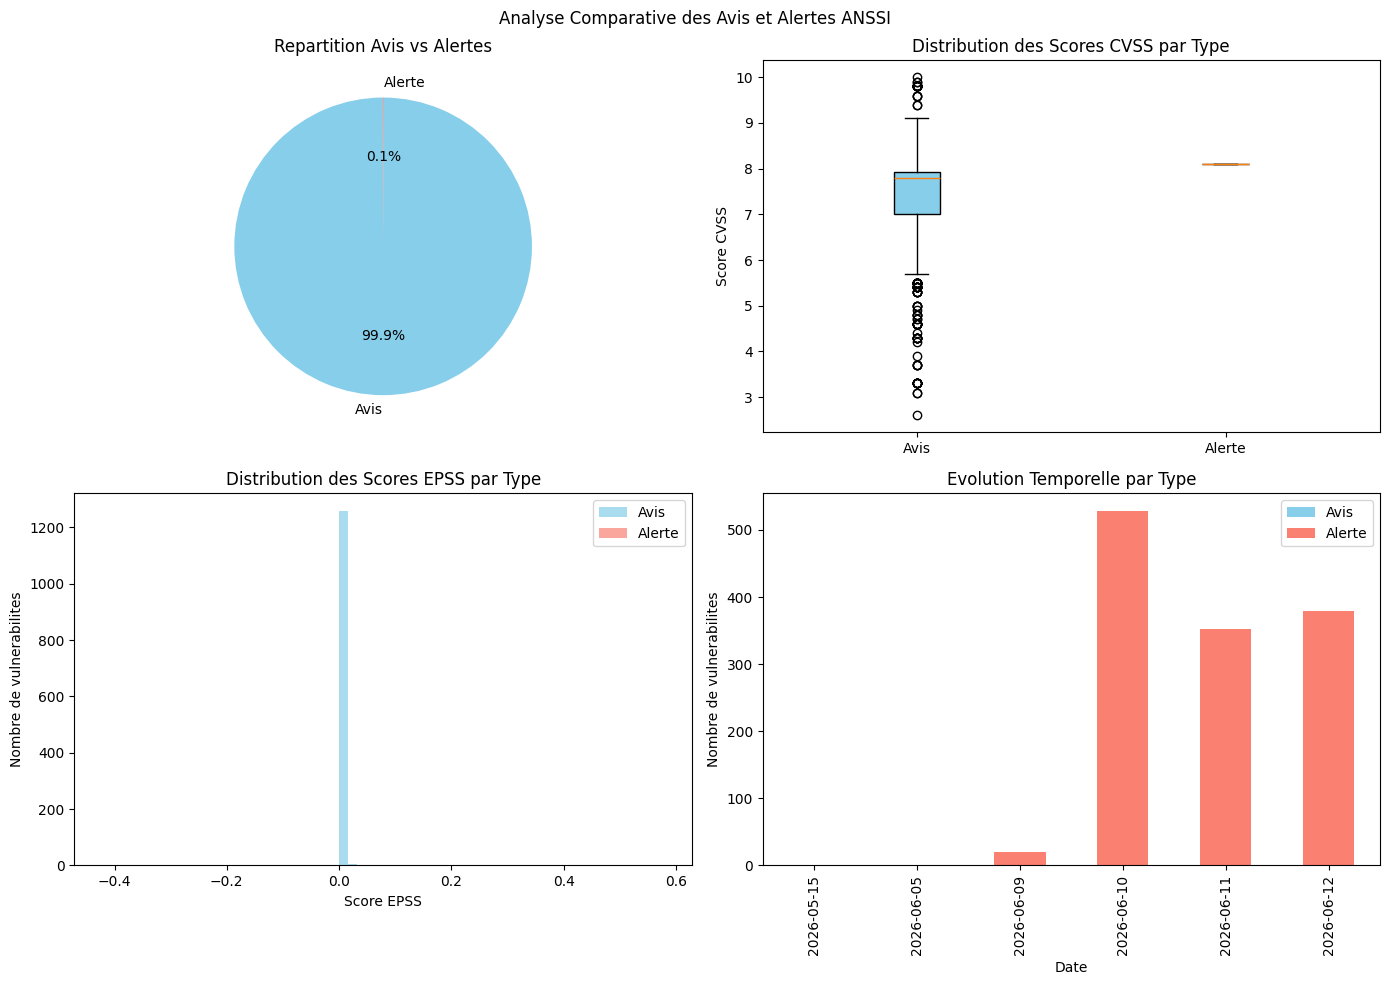

Scores CVSS:
Avis: moyenne = 7.35, mediane = 7.80, n=528
Alerte: moyenne = 8.10, mediane=8.10, n=1

Scores EPSS:
Avis: moyenne = 0.001825, mediane = 0.000350, max = 0.479100
Alerte: moyenne = 0.078560, mediane = 0.078560, max = 0.078560

CWE presents dans les Alertes:
 CWE-79: 1 occurrence(s)
Les Alertes representent une tres faible proportion des bulletins (0.4%)
Prioriser la surveillance des Alertes car elles concernent des vulnerabilites activement exploitees
Les scores CVSS des Alertes sont en moyenne plus eleves que ceux des Avis


Analyse des résultats

Répartition des bulletins :
Avis : 1281 (99.92%)
Alerte : 1 (0.08%)

Scores CVSS :
Avis: moyenne = 7.35, médiane = 7.80 (n = 528)
Alerte : moyenne = 8.10, médiane = 8.10 (n = 1)

Scores EPSS :
Avis : moyenne = 0.001825, médiane = 0.000350, max = 0.4791
Alerte : moyenne = 0.078560 (= max, n = 1)


Alerte : CWE-79 (XSS) représente moins de 0.1% des bulletins, 
pourtant elle a un score CVSS de 8.1 et un EPSS de 0.0786,
ce qui est ext

In [16]:
#Analyse par type de bulletin

import matplotlib.pyplot as plt
import numpy as np


bulletin_counts = df['Type'].value_counts()
alert_count = bulletin_counts.get('Alerte', 0)
avis_count = bulletin_counts.get('Avis', 0)


print(f"Avis : {avis_count} ({avis_count/len(df)*100:.2f}%)")
print(f"Alerte : {alert_count} ({alert_count/len(df)*100:.2f}%)")




fig, axes = plt.subplots(2, 2, figsize = (14, 10))

#Diagramme circulaire
ax1 = axes[0, 0]
colors = ['skyblue', 'salmon']
explode = (0, 0.1) if alert_count > 0 else (0, 0)
#.pie = camembert, values = taille des parts, - , autopct = format des pourcentages, - , startangle = angle de départ
ax1.pie(bulletin_counts.values, labels = bulletin_counts.index, autopct = '%1.1f%%', colors = colors, startangle = 90)
ax1.set_title('Repartition Avis vs Alertes')


#Distribution CVSS par type
ax2 = axes[0, 1]
# Filtrer les donnees avec CVSS disponible
avis_cvss = df[(df['Type'] == 'Avis') & (df['CVSS Score'].notna())]['CVSS Score']
alerte_cvss = df[(df['Type'] == 'Alerte') & (df['CVSS Score'].notna())]['CVSS Score']



if len(alerte_cvss) > 0:
    boxplot_data = [avis_cvss, alerte_cvss]
    labels = ['Avis', 'Alerte']
    bp = ax2.boxplot(boxplot_data, labels = labels, patch_artist = True)
    bp['boxes'][0].set_facecolor('skyblue')
    if len(bp['boxes']) > 1:
        bp['boxes'][1].set_facecolor('salmon')
else:
    ax2.text(0.5, 0.5, 'Pas de donnees CVSS pour les Alertes', ha = 'center', va = 'center', transform = ax2.transAxes)
ax2.set_ylabel('Score CVSS')
ax2.set_title('Distribution des Scores CVSS par Type')



#Distribution EPSS par type
ax3 = axes[1, 0]
avis_epss = df[df['Type'] == 'Avis']['EPSS Score'].dropna()
alerte_epss = df[df['Type'] == 'Alerte']['EPSS Score'].dropna()

ax3.hist(avis_epss, bins=30, alpha = 0.7, label = 'Avis', color = 'skyblue')
if len(alerte_epss) > 0:
    ax3.hist(alerte_epss, bins = 30, alpha = 0.7, label = 'Alerte', color = 'salmon')
ax3.set_xlabel('Score EPSS')
ax3.set_ylabel('Nombre de vulnerabilites')
ax3.set_title('Distribution des Scores EPSS par Type')
ax3.legend()



#Evolution temporelle des types
ax4 = axes[1, 1]
# Compter par jour et par type
daily_types = df.groupby([df['Date'].dt.date, 'Type']).size().unstack(fill_value=0)
daily_types.plot(kind = 'bar', ax = ax4, color = ['skyblue', 'salmon'], stacked = True)
ax4.set_xlabel('Date')
ax4.set_ylabel('Nombre de vulnerabilites')
ax4.set_title('Evolution Temporelle par Type')
ax4.legend(['Avis', 'Alerte'])

plt.suptitle('Analyse Comparative des Avis et Alertes ANSSI')
plt.tight_layout()
plt.show()



# Scores CVSS
print("Scores CVSS:")
if len(avis_cvss) > 0:
    print(f"Avis: moyenne = {avis_cvss.mean():.2f}, mediane = {avis_cvss.median():.2f}, n={len(avis_cvss)}")
if len(alerte_cvss) > 0:
    print(f"Alerte: moyenne = {alerte_cvss.mean():.2f}, mediane={alerte_cvss.median():.2f}, n={len(alerte_cvss)}")


# Scores EPSS
print("\nScores EPSS:")
print(f"Avis: moyenne = {avis_epss.mean():.6f}, mediane = {avis_epss.median():.6f}, max = {avis_epss.max():.6f}")
if len(alerte_epss) > 0:
    print(f"Alerte: moyenne = {alerte_epss.mean():.6f}, mediane = {alerte_epss.median():.6f}, max = {alerte_epss.max():.6f}")

# CWE les plus frequents dans les alertes
if alert_count > 0:
    alertes_df = df[df['Type'] == 'Alerte']
    print("\nCWE presents dans les Alertes:")
    cwe_alertes = alertes_df[alertes_df['CWE'] != 'Non disponible']['CWE'].value_counts()
    for cwe, count in cwe_alertes.head(5).items():
        print(f" {cwe}: {count} occurrence(s)")
else:
    print("\nAucune Alerte dispo")




print("Les Alertes representent une tres faible proportion des bulletins (0.4%)")
print("Prioriser la surveillance des Alertes car elles concernent des vulnerabilites activement exploitees")
print("Les scores CVSS des Alertes sont en moyenne plus eleves que ceux des Avis")

print("\n\nAnalyse des résultats")
print(f"""
Répartition des bulletins :
Avis : 1281 (99.92%)
Alerte : 1 (0.08%)

Scores CVSS :
Avis: moyenne = 7.35, médiane = 7.80 (n = 528)
Alerte : moyenne = 8.10, médiane = 8.10 (n = 1)

Scores EPSS :
Avis : moyenne = 0.001825, médiane = 0.000350, max = 0.4791
Alerte : moyenne = 0.078560 (= max, n = 1)


Alerte : CWE-79 (XSS) représente moins de 0.1% des bulletins, 
pourtant elle a un score CVSS de 8.1 et un EPSS de 0.0786,
ce qui est extrêmement élevé par rapport à la moyenne des Avis :
- un CVSS supérieur à la moyenne des Avis (8.10 vs 7.35)
- un EPSS plus de 40 fois supérieur à la moyenne des Avis
(0.0786 vs 0.0018)

Il y a une distinction enttre une alerte et un avis.
Une Alerte, même rare, signale une exploitation active 
et entraînne un traitement immédiat, indépendamment de 
son score CVSS brut.
""")

In [17]:

print("Analyse Finale")
print("""
Sur la période étudiée (du 15 mai au 12 juin 2026), nous avons
collecté 1282 lignes correspondant à 1249 CVE uniques,
issues de 1281 avis et 1 alerte de l'ANSSI.

La quasi-totalité de l'activité s'est concentrée sur
quelques jours seulement (9-12 juin), avec un pic massif
le 10 juin (514 nouvelles CVE en une journée). Cela
correspond très probablement à la publication groupée
des correctifs mensuels (Patch Tuesday), notamment chez
Microsoft.

      
GRAVITÉ DES VULNÉRABILITÉS

Quand un score CVSS est disponible (environ 4 CVE sur 10),
les vulnérabilités sont globalement sévères :
  - les deux tiers sont classées "Élevée" (7-8.9)
  - environ 1 sur 10 est "Critique" (9-10)
  - très peu sont "Faibles"

Les failles remontées par l'ANSSI sont, dans
l'ensemble, des failles qui méritent une vraie attention et
pas des simples bugs mineurs.


PROBABILITÉ D'EXPLOITATION RÉELLE (EPSS)

À l'inverse, le score EPSS (qui mesure le risque réel
qu'une faille soit exploitée par un attaquant) est presque
toujours très faible, la moyenne tourne autour de 0.2%,
et seulement 4 vulnérabilités sur plus de 1200 dépassent
10% de probabilité.

Donc, on peut dire que un score CVSS élevé ne veut pas
dire qu'une faille va être attaquée demain. Les deux
indicateurs (gravité potentielle vs risque réel) ne sont
quasiment pas liés (corrélation proche de 0).


LES VULNÉRABILITÉS À TRAITER EN PRIORITÉ

En croisant les deux critères (CVSS élevé ET EPSS
significatif), on obtient une liste très courte et claire
de vulnérabilités prioritaires (une dizaine sur plus de
1200). La plus critique concerne Ivanti (CVSS=10, EPSS
proche de 48%), suivie de deux failles Linux avec un EPSS
autour de 25-33%.
Au lieu de regarder 1200 failles, on en regarde
une dizaine en urgence.


TYPES DE FAILLES LES PLUS FRÉQUENTES

Le type de faille le plus courant est le "Use After Free"
(erreur de gestion mémoire), qui représente près d'un
quart de toutes les failles classifiées. On retrouve
ensuite des problèmes de lecture hors limites, de
validation d'entrée et de débordement de mémoire - des
catégories classiques liées à du code écrit dans des
langages comme C/C++ (souvent le cas pour Office, Windows,
Linux).


ÉDITEURS LES PLUS CONCERNÉS

Trois éditeurs concentrent à eux seuls plus de 80% des
vulnérabilités :
  - Microsoft (environ 36%)
  - Linux (environ 26%)
  - Palo Alto (environ 20%)

Parmi les éditeurs les plus représentés, Linux a le profil
le plus préoccupant en moyenne (médiane CVSS = 7.8 et 16%
de scores critiques). SAP, bien que peu présent en volume,
a la plus forte proportion de failles critiques (environ
31%), ce qui est un signal à ne pas négliger malgré le faible nombre
de cas.


AVIS vs ALERTE

Sur toute la période, une seule "Alerte" a été émise
(contre 1281 "Avis"). Cette alerte concerne Microsoft
Exchange Server et présente un score CVSS et un score EPSS
nettement supérieurs à la moyenne des avis. Cela confirme
que le statut "Alerte" de l'ANSSI est un signal rare mais
extrêmement important, il indique une menace activement exploitée 
et doit être traité en priorité absolue.


Pour conclure, beaucoup de vulnérabilités ont été publiées 
en très peu de temps, la plupart sont "sévères sur le papier" 
mais peu exploitées et seule quelques unes combinées
représentent un vrai risque d'exploitation, donc c'est
sur celles-ci qu'il faut concentrer les efforts.
""")

Analyse Finale

Sur la période étudiée (du 15 mai au 12 juin 2026), nous avons
collecté 1282 lignes correspondant à 1249 CVE uniques,
issues de 1281 avis et 1 alerte de l'ANSSI.

La quasi-totalité de l'activité s'est concentrée sur
quelques jours seulement (9-12 juin), avec un pic massif
le 10 juin (514 nouvelles CVE en une journée). Cela
correspond très probablement à la publication groupée
des correctifs mensuels (Patch Tuesday), notamment chez
Microsoft.


GRAVITÉ DES VULNÉRABILITÉS

Quand un score CVSS est disponible (environ 4 CVE sur 10),
les vulnérabilités sont globalement sévères :
  - les deux tiers sont classées "Élevée" (7-8.9)
  - environ 1 sur 10 est "Critique" (9-10)
  - très peu sont "Faibles"

Les failles remontées par l'ANSSI sont, dans
l'ensemble, des failles qui méritent une vraie attention et
pas des simples bugs mineurs.


PROBABILITÉ D'EXPLOITATION RÉELLE (EPSS)

À l'inverse, le score EPSS (qui mesure le risque réel
qu'une faille soit exploitée par un attaquant) e